### Mini Project IX

#### Part 1 — Exploration & Preprocessing

Content moderation dataset exploration, EDA, cleaning, and train/val/test split.

In [4]:
# Install dependencies (run once)
!pip install -q transformers==4.40.0 datasets==2.19.0 accelerate==0.30.0 wordcloud

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

In [5]:
# Imports and device setup
import re
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option("display.max_columns", None)

print("✅ Imports loaded")

✅ Imports loaded


Total samples: 24,783
label_name
Offensive      19190
Neither         4163
Hate Speech     1430
Name: count, dtype: int64
label_name
Offensive      77.43
Neither        16.80
Hate Speech     5.77
Name: proportion, dtype: float64
            char_len                                            word_count  \
               count  mean   std  min   25%   50%    75%    max      count   
label_name                                                                   
Hate Speech   1430.0  84.6  40.5  5.0  49.0  82.0  121.0  254.0     1430.0   
Neither       4163.0  94.9  41.1  7.0  60.0  97.0  132.0  522.0     4163.0   
Offensive    19190.0  83.5  41.5  5.0  50.0  78.0  115.0  754.0    19190.0   

                                                    
             mean  std  min  25%   50%   75%   max  
label_name                                          
Hate Speech  13.9  7.0  1.0  8.0  13.5  20.0  32.0  
Neither      14.9  6.8  1.0  9.0  15.0  20.0  52.0  
Offensive    14.0  6.8  1.0  8.0  13.

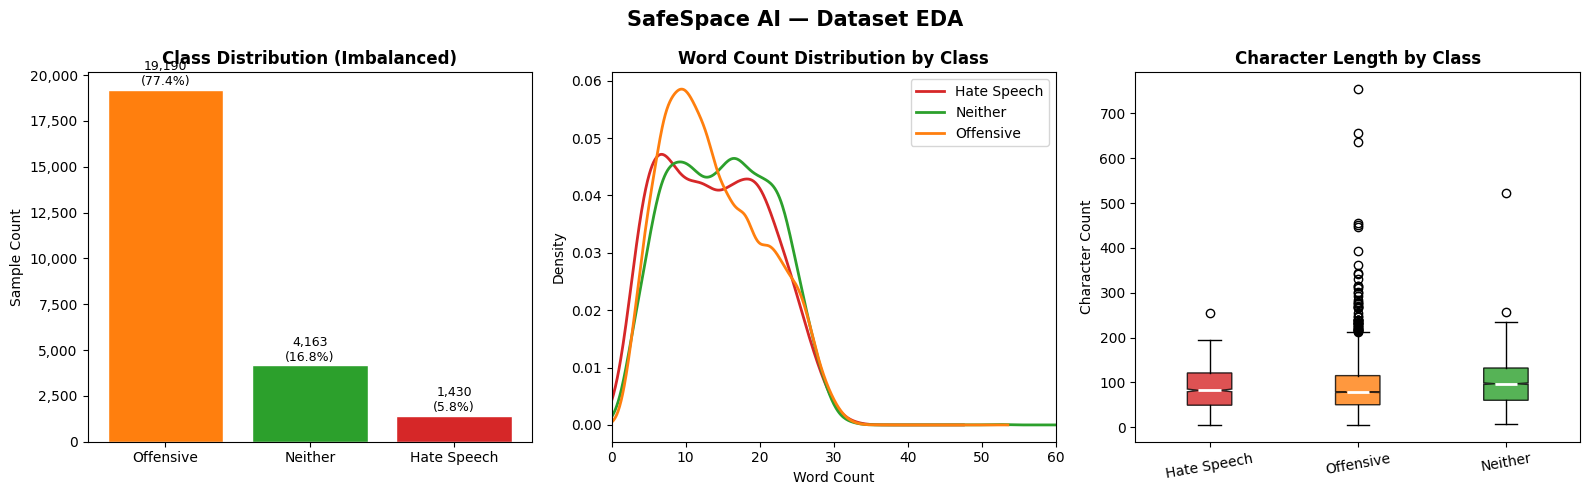


Hate Speech (class 0)
  1. [USER] I do not like talking to you faggot and I did but in a nicely way fag
  2. RT [USER]: [USER]:What straight guys take a picture of themselves naked in a hot tun.What fags [USER] [USER] [USER]&8230;
  3. [USER] [USER] AMERICA today, the rule of thumb is: when in doubt, blame "whitey"
  4. [USER] you tell me, coon.

Offensive (class 1)
  1. Why is it everytime I go to cracker barrel the girl with great tits that seats you who is your waitress nope its the chick with 2 teeth
  2. Run that nigga, you don't want that nigga, but I need a bad bitch that's hotter than me
  3. I need a girl from Jamaica I can't fuck with these basic black bitches
  4. RT [USER]: I know you have me blocked, but next week bitch [USER]

Neither (class 2)
  1. RT [USER]: Chicago will not refund $7.7 million made from red light tickets issued after yellow lights were shortened [URL]
  2. Sometimes, even I gotta tell these hoes to grow up smh
  3. &8216;Chillin&8217; With My Homie Or

IsADirectoryError: [Errno 21] Is a directory: 'npy_files/X_train.npy'

In [ ]:
# Data load, exploration, and preprocessing

CLASS_NAMES = {0: "Hate Speech", 1: "Offensive", 2: "Neither"}
PALETTE = {"Hate Speech": "#d62728", "Offensive": "#ff7f0e", "Neither": "#2ca02c"}

# Download dataset from GitHub if not already present
DATA_URL = (
    "https://raw.githubusercontent.com/t-davidson/"
    "hate-speech-and-offensive-language/master/data/labeled_data.csv"
)
DATA_PATH = "labeled_data.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

# Load and create readable labels

df = pd.read_csv(DATA_PATH, index_col=0)
df["label_name"] = df["class"].map(CLASS_NAMES)

# Basic dataset info
print(f"Total samples: {len(df):,}")
print(df["label_name"].value_counts())
print(df["label_name"].value_counts(normalize=True).mul(100).round(2))

# Text length features

df["char_len"] = df["tweet"].str.len()
df["word_count"] = df["tweet"].str.split().str.len()
print(df.groupby("label_name")[["char_len", "word_count"]].describe().round(1))

# Plots: class distribution, word count KDE, character length boxplot

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("SafeSpace AI — Dataset EDA", fontsize=15, fontweight="bold")

counts = df["label_name"].value_counts()
ax = axes[0]
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[k] for k in counts.index], edgecolor="white")
ax.set_title("Class Distribution (Imbalanced)", fontweight="bold")
ax.set_ylabel("Sample Count")
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
for label, grp in df.groupby("label_name"):
    grp["word_count"].plot.kde(ax=ax, label=label, color=PALETTE[label], linewidth=2)
ax.set_title("Word Count Distribution by Class", fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Density")
ax.set_xlim(0, 60)
ax.legend()

ax = axes[2]
order = ["Hate Speech", "Offensive", "Neither"]
data_by_class = [df[df["label_name"] == c]["char_len"].values for c in order]
bp = ax.boxplot(data_by_class, patch_artist=True, notch=True,
                medianprops=dict(color="white", linewidth=2))
for patch, label in zip(bp["boxes"], order):
    patch.set_facecolor(PALETTE[label])
    patch.set_alpha(0.8)
ax.set_xticklabels(order, rotation=10)
ax.set_title("Character Length by Class", fontweight="bold")
ax.set_ylabel("Character Count")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# Clean tweet text: remove URLs, normalize mentions/hashtags, strip non-ASCII

def clean_tweet(text: str) -> str:
    text = re.sub(r"&amp;", "&", text)
    text = re.sub(r"&lt;",  "<", text)
    text = re.sub(r"&gt;",  ">", text)
    text = re.sub(r"http\S+|www\.\S+", "[URL]",  text)
    text = re.sub(r"@\w+",             "[USER]", text)
    text = re.sub(r"#(\w+)",           r"\1",    text)
    text = text.encode("ascii", errors="ignore").decode()
    text = re.sub(r"([!?.]){2,}", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_tweet"] = df["tweet"].apply(clean_tweet)

# 4 examples per class to show nuances between categories

N_EXAMPLES = 4
for cls, name in CLASS_NAMES.items():
    print(f"\n{name} (class {cls})")
    samples = df[df["class"] == cls]["clean_tweet"].sample(N_EXAMPLES, random_state=SEED)
    for i, text in enumerate(samples, 1):
        print(f"  {i}. {text[:140]}")

# Word clouds per class (requires: pip install wordcloud)

try:
    from wordcloud import WordCloud
    WC_COLORS = {"Hate Speech": "Reds", "Offensive": "Oranges", "Neither": "Greens"}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Word Clouds by Class", fontsize=14, fontweight="bold")
    for ax, (cls, name) in zip(axes, CLASS_NAMES.items()):
        corpus = " ".join(df[df["class"] == cls]["clean_tweet"])
        wc = WordCloud(width=600, height=400, background_color="white",
                       colormap=WC_COLORS[name], max_words=80,
                       collocations=False).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(name, fontweight="bold", color=list(PALETTE.values())[cls])
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("wordclouds.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("Install wordcloud to generate word clouds: pip install wordcloud")

# Stratified 70/15/15 split to preserve class ratios across partitions

X, y = df["clean_tweet"].values, df["class"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Split summary table

split_summary = []
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    row = {"Split": split_name, "Total": len(split_y)}
    for cls, name in CLASS_NAMES.items():
        cnt = np.sum(split_y == cls)
        row[name] = f"{cnt} ({cnt/len(split_y)*100:.1f}%)"
    split_summary.append(row)

print(pd.DataFrame(split_summary).set_index("Split").to_string())

# Save splits for use in subsequent notebooks
# Use a writable local directory rather than `/data`, which may be read-only
for name, arr in [("X_train", X_train), ("y_train", y_train),
                  ("X_val",   X_val),   ("y_val",   y_val),
                  ("X_test",  X_test),  ("y_test",  y_test)]:
    path = os.path.join("/data/npy_files", f"{name}.npy")
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        np.save(path, arr)
